# Explainable AI (XAI) using SHAP

In this notebook, we use SHAP (SHapley Additive exPlanations) to explain the predictions of our trained LightGBM model. SHAP allows us to understand both **global** feature importance (which features matter most overall) and **local** feature importance (why the model made a specific prediction for a single file).

In [1]:
import os
import sys

# Ensure the paths to the virtual environment(s) are added BEFORE importing packages
base_dir = os.getcwd()

# 1. Check local venv first
for venv_folder in ["venv", ".venv"]:
    site_packages = os.path.join(base_dir, venv_folder, "Lib", "site-packages")
    if os.path.exists(site_packages) and site_packages not in sys.path:
        sys.path.insert(0, site_packages)
        break

# 2. Specifically add the global venv path where we installed shap
global_venv_site_packages = r"Z:\ai project\.venv\Lib\site-packages"
if os.path.exists(global_venv_site_packages) and global_venv_site_packages not in sys.path:
    sys.path.insert(0, global_venv_site_packages)

# Now it is safe to import these libraries
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

try:
    from thrember.features import PEFeatureExtractor
    print("Features extractor imported successfully.")
except ImportError:
    print("Warning: 'thrember' not found. Will use default feature dimension (2381).")
    class PEFeatureExtractor:
        dim = 2381

Z:\ai project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Features extractor imported successfully.


In [2]:
# Load the tuned LightGBM model
DATASET_DIR = r"Z:\ember2024_train_data"
model_path = os.path.join(DATASET_DIR, "ember_model_tuned_full.txt")

print(f"Loading model from {model_path}...")
model = lgb.Booster(model_file=model_path)
print("Model loaded successfully!")

Loading model from Z:\ember2024_train_data\ember_model_tuned_full.txt...
Model loaded successfully!


In [3]:
# Load a small sample of the validation data for SHAP
# SHAP can be computationally expensive, so we take a strict random sample of 2000 points.
# Since we didn't create a standalone 'X_val.dat', the validation split is the last 10% of 'X_train.dat'
X_data_path = os.path.join(DATASET_DIR, "X_train.dat")
y_data_path = os.path.join(DATASET_DIR, "y_train.dat")

extractor = PEFeatureExtractor()
ndim = extractor.dim

file_size = os.path.getsize(X_data_path)
nrows = file_size // (ndim * 4)

# Open memory-mapped files without consuming all RAM
X_memmap = np.memmap(X_data_path, dtype=np.float32, mode="r", shape=(nrows, ndim))
y_memmap = np.memmap(y_data_path, dtype=np.int32, mode="r", shape=(nrows,))

# Our standard training pipeline leaves the last 10% for validation:
train_nrows = int(nrows * 0.9)
val_nrows = nrows - train_nrows

np.random.seed(42)
sample_size = 2000  # 2k samples is enough for reliable global explanations

# Sample randomly strictly from the validation slice (the final 10% of indices)
random_indices = np.random.choice(np.arange(train_nrows, nrows), size=sample_size * 2, replace=False)

X_sample = np.array(X_memmap[random_indices])
y_sample = np.array(y_memmap[random_indices])

# Filter out unlabeled (-1)
valid_idx = y_sample != -1
X_sample = X_sample[valid_idx][:sample_size]
y_sample = y_sample[valid_idx][:sample_size]

print(f"Sampled {len(X_sample)} valid validation records for SHAP analysis.")

Sampled 2000 valid validation records for SHAP analysis.


In [4]:
# The EMBER/Thrember dataset extracts features in specific "blocks".
# Since the features are just returned as a massive 1D array of numbers, 
# we can map the index of the array back to the block it came from!

# Let's extract the actual names and dimensions dynamically from our PEFeatureExtractor
feature_blocks = extractor.features
print("Extracted feature blocks and their sizes:")

feature_names = []
for block in feature_blocks:
    name = block.name
    size = block.dim
    print(f" - {name}: {size} features")
    # For each number in the block, we assign it a readable name (e.g. "strings_005")
    for i in range(size):
        feature_names.append(f"{name}_{i}")

# For example, if you wanted to know what feature 2405 is:
test_idx = 2405
print(f"\nFeature {test_idx} belongs to: {feature_names[test_idx]}")

Extracted feature blocks and their sizes:
 - general: 7 features
 - histogram: 256 features
 - byteentropy: 256 features
 - strings: 177 features
 - header: 74 features
 - section: 224 features
 - imports: 1282 features
 - exports: 129 features
 - datadirectories: 34 features
 - richheader: 33 features
 - authenticode: 8 features
 - pefilewarnings: 88 features

Feature 2405 belongs to: datadirectories_0


In [5]:
# Initialize the SHAP TreeExplainer
print("Calculating SHAP values... (This might take a minute)")
explainer = shap.TreeExplainer(model)

# Get SHAP values for out sample
shap_values = explainer.shap_values(X_sample)
print("SHAP values calculated successfully!")

Calculating SHAP values... (This might take a minute)
SHAP values calculated successfully!


Z:\ai project\.venv\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### Global Explanations
Let's look at which features are most important globally across our sampled dataset. The **Bar Plot** gives us the magnitude of importance, while the **Beeswarm Plot** shows how different values of those features push the model toward 'Malicious' or 'Benign'.

C:\Users\him\AppData\Local\Temp\ipykernel_7728\528273586.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", feature_names=feature_names)


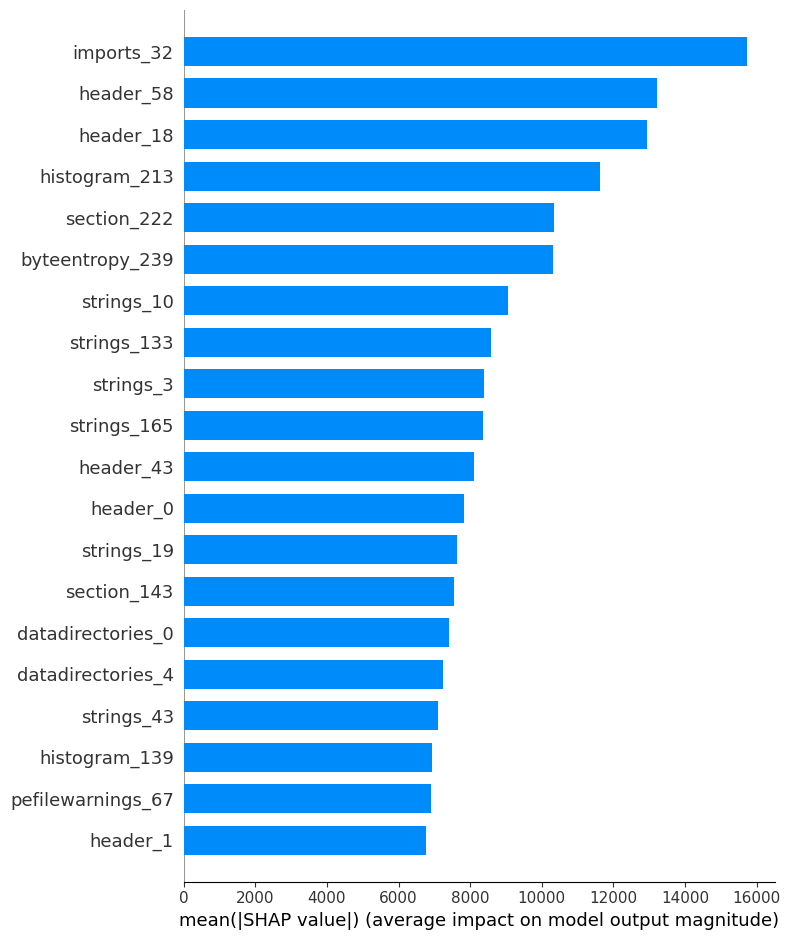

In [6]:
# 1. SHAP Summary Plot (Bar)
# This shows the average absolute SHAP value magnitude across all samples.
# Notice we added `feature_names=feature_names` to show human readable categories!
shap.summary_plot(shap_values, X_sample, plot_type="bar", feature_names=feature_names)

C:\Users\him\AppData\Local\Temp\ipykernel_7728\288476241.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feature_names)


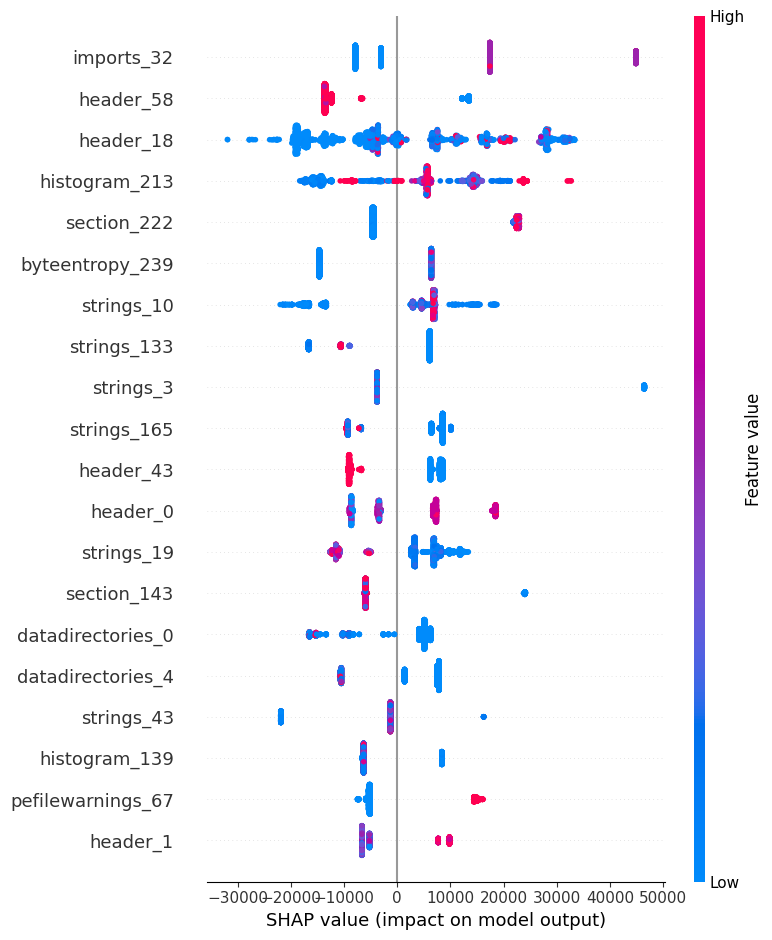

In [7]:
# 2. SHAP Summary Plot (Beeswarm)
# This shows the distribution of SHAP values for the top features.
# Red = High feature value, Blue = Low feature value.
# Positive SHAP value = pushes towards Malicious.
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)

### Local Explanations
Now let's look at how the model made its decision for a **single** sample (e.g., one malicious, one benign). This is extremely useful for forensics, as it tells an analyst exactly *why* the model flagged a specific file as malware.

Explaining Malicious Prediction (Actual Class: 1)


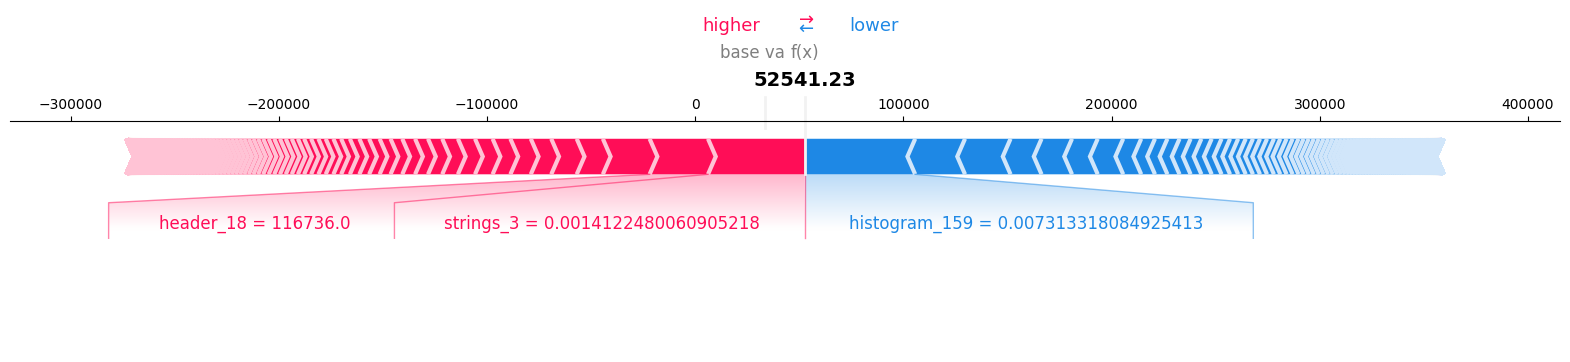

In [8]:
# Find indices for one malicious and one benign file
malicious_idx = np.where(y_sample == 1)[0][0]
benign_idx = np.where(y_sample == 0)[0][0]

# Get correct expected value and shap values
ev = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"Explaining Malicious Prediction (Actual Class: {y_sample[malicious_idx]})")
shap.initjs()

# Force plot for a malicious file, now with readable names
shap.force_plot(
    ev, 
    sv[malicious_idx, :], 
    X_sample[malicious_idx, :], 
    feature_names=feature_names, 
    matplotlib=True
)

Explaining Benign Prediction (Actual Class: 0)


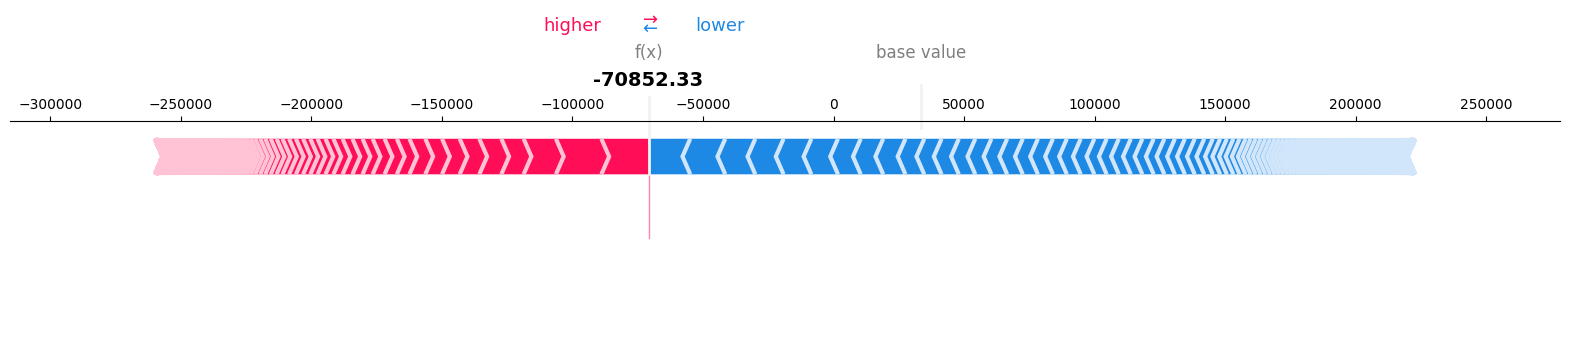

In [9]:
print(f"Explaining Benign Prediction (Actual Class: {y_sample[benign_idx]})")

# Force plot for a benign file, now with readable names
shap.force_plot(
    ev, 
    sv[benign_idx, :], 
    X_sample[benign_idx, :], 
    feature_names=feature_names, 
    matplotlib=True
)